In [1]:
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm


In [2]:
Cosmos_accu_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu/Cosmos_dict.pt', weights_only=False)
Cosmos_subject_accu_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu/Cosmos_dict_subject.pt', weights_only=False)

In [3]:
def barplot_annotate_brackets(num1, num2, data, center, height, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """
    Annotate barplot with p-values.

    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """

    if type(data) is str:
        text = data
    else:
        # * is p < 0.01
        # ** is p < 0.001
        # *** is p < 0.0001
        # etc.
        text = ''
        p = .01

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    plt.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    plt.text(*mid, text, **kwargs)

/tmp/ipython-input-747012146.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
/tmp/ipython-input-747012146.py:23: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  g = sns.barplot(


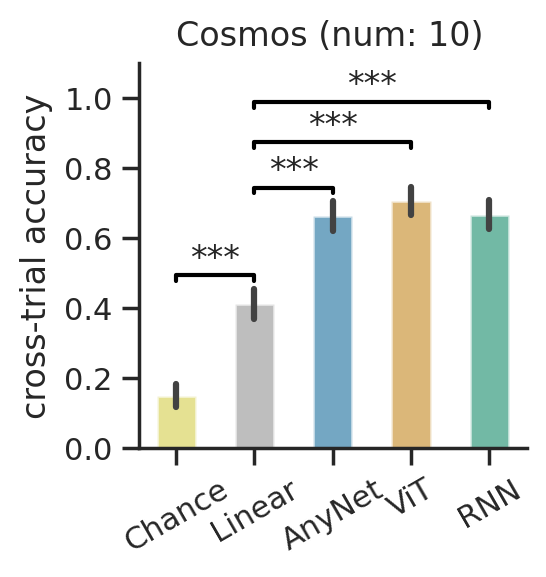

In [19]:
color_list = sns.color_palette('colorblind')
color_list_define = []
color_list_define.append(color_list[-2])
color_list_define.append(color_list[-3])
for ii in range(0, 5):
    color_list_define.append(color_list[ii])

_, p_cl = sp.stats.ttest_ind(np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'Chance']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'Linear']['acu_test']), equal_var=False)

_, p_la = sp.stats.ttest_ind(np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'Linear']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'AnyNet']['acu_test']), equal_var=False)

_, p_lv = sp.stats.ttest_ind(np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'Linear']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'ViT']['acu_test']), equal_var=False)

_, p_lr = sp.stats.ttest_ind(np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'Linear']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'RNN']['acu_test']), equal_var=False)

sns.set_theme(style='ticks')
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(2.5, 2.5), dpi=200)
g = sns.barplot(
    data=Cosmos_accu_dict,
    x='model_type', y='acu_test',
    errorbar='sd', width=0.5, palette=color_list_define, alpha=.6
)

barplot_annotate_brackets(1, 2, p_cl, np.array([0, 0, 1, 1]),
                          [0.2, 0.2, 0.4, 0.4], dh=0.1, barh=.02, maxasterix=3)
barplot_annotate_brackets(1, 2, p_la, np.array([1, 1, 2, 2]),
                          [0.2, 0.2, 0.65, 0.65], dh=0.1, barh=.02, maxasterix=3)
barplot_annotate_brackets(1, 2, p_cl, np.array([1, 1, 3, 3]),
                          [0.2, 0.2, 0.78, 0.78], dh=0.1, barh=.02, maxasterix=3)
barplot_annotate_brackets(1, 2, p_cl, np.array([1, 1, 4, 4]),
                          [0.2, 0.2, 0.88, 0.88], dh=0.1, barh=.02, maxasterix=3)

plt.ylim([0, 1.1])
plt.ylabel('cross-trial accuracy')
plt.xlabel('')
plt.xticks(rotation=30)
sns.despine()
plt.text(0, 1.15, 'Cosmos (num: 10)')
plt.show()

/tmp/ipython-input-3833012797.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
/tmp/ipython-input-3833012797.py:23: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  g = sns.barplot(


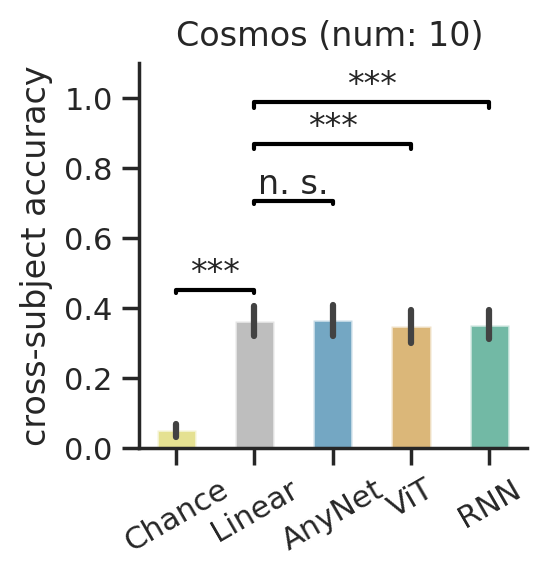

In [10]:
color_list = sns.color_palette('colorblind')
color_list_define = []
color_list_define.append(color_list[-2])
color_list_define.append(color_list[-3])
for ii in range(0, 5):
    color_list_define.append(color_list[ii])

_, p_cl = sp.stats.ttest_ind(np.array(Cosmos_subject_accu_dict[Cosmos_subject_accu_dict['model_type'] == 'Chance']['acu_test_subject']),
                   np.array(Cosmos_subject_accu_dict[Cosmos_subject_accu_dict['model_type'] == 'Linear']['acu_test_subject']), equal_var=False)

_, p_la = sp.stats.ttest_ind(np.array(Cosmos_subject_accu_dict[Cosmos_subject_accu_dict['model_type'] == 'Linear']['acu_test_subject']),
                   np.array(Cosmos_subject_accu_dict[Cosmos_subject_accu_dict['model_type'] == 'AnyNet']['acu_test_subject']), equal_var=False)

_, p_lv = sp.stats.ttest_ind(np.array(Cosmos_subject_accu_dict[Cosmos_subject_accu_dict['model_type'] == 'Linear']['acu_test_subject']),
                   np.array(Cosmos_subject_accu_dict[Cosmos_subject_accu_dict['model_type'] == 'ViT']['acu_test_subject']), equal_var=False)

_, p_lr = sp.stats.ttest_ind(np.array(Cosmos_subject_accu_dict[Cosmos_subject_accu_dict['model_type'] == 'Linear']['acu_test_subject']),
                   np.array(Cosmos_subject_accu_dict[Cosmos_subject_accu_dict['model_type'] == 'RNN']['acu_test_subject']), equal_var=False)

sns.set_theme(style='ticks')
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(2.5, 2.5), dpi=200)
g = sns.barplot(
    data=Cosmos_subject_accu_dict,
    x='model_type', y='acu_test_subject',
    errorbar='sd', width=0.5, palette=color_list_define, alpha=.6
)

barplot_annotate_brackets(1, 2, p_cl, np.array([0, 0, 1, 1]),
                          [0.2, 0.2, 0.4, 0.4], dh=0.1, barh=.02, maxasterix=3)
barplot_annotate_brackets(1, 2, p_la, np.array([1, 1, 2, 2]),
                          [0.2, 0.2, 0.65, 0.65], dh=0.1, barh=.02, maxasterix=3)
barplot_annotate_brackets(1, 2, p_cl, np.array([1, 1, 3, 3]),
                          [0.2, 0.2, 0.78, 0.78], dh=0.1, barh=.02, maxasterix=3)
barplot_annotate_brackets(1, 2, p_cl, np.array([1, 1, 4, 4]),
                          [0.2, 0.2, 0.88, 0.88], dh=0.1, barh=.02, maxasterix=3)

plt.ylim([0, 1.1])
plt.ylabel('cross-subject accuracy')
plt.xlabel('')
plt.xticks(rotation=30)
sns.despine()
plt.text(0, 1.15, 'Cosmos (num: 10)')
plt.show()

In [11]:
Cosmos_acronym_accu_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu/Cosmos_dict_acronym.pt', weights_only=False)

In [12]:
Cosmos_acronym_accu_dict

,acu_test,model_type,acronym_test
0,0.773438,AnyNet,Isocortex
1,0.765625,AnyNet,Isocortex
2,0.750000,AnyNet,Isocortex
3,0.781250,AnyNet,Isocortex
4,0.742188,AnyNet,Isocortex
...,...,...,...
2842,0.812500,RNN,CB
2843,0.671875,RNN,CB
2844,0.765625,RNN,CB
2845,0.804688,RNN,CB


/tmp/ipython-input-241324731.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.barplot(


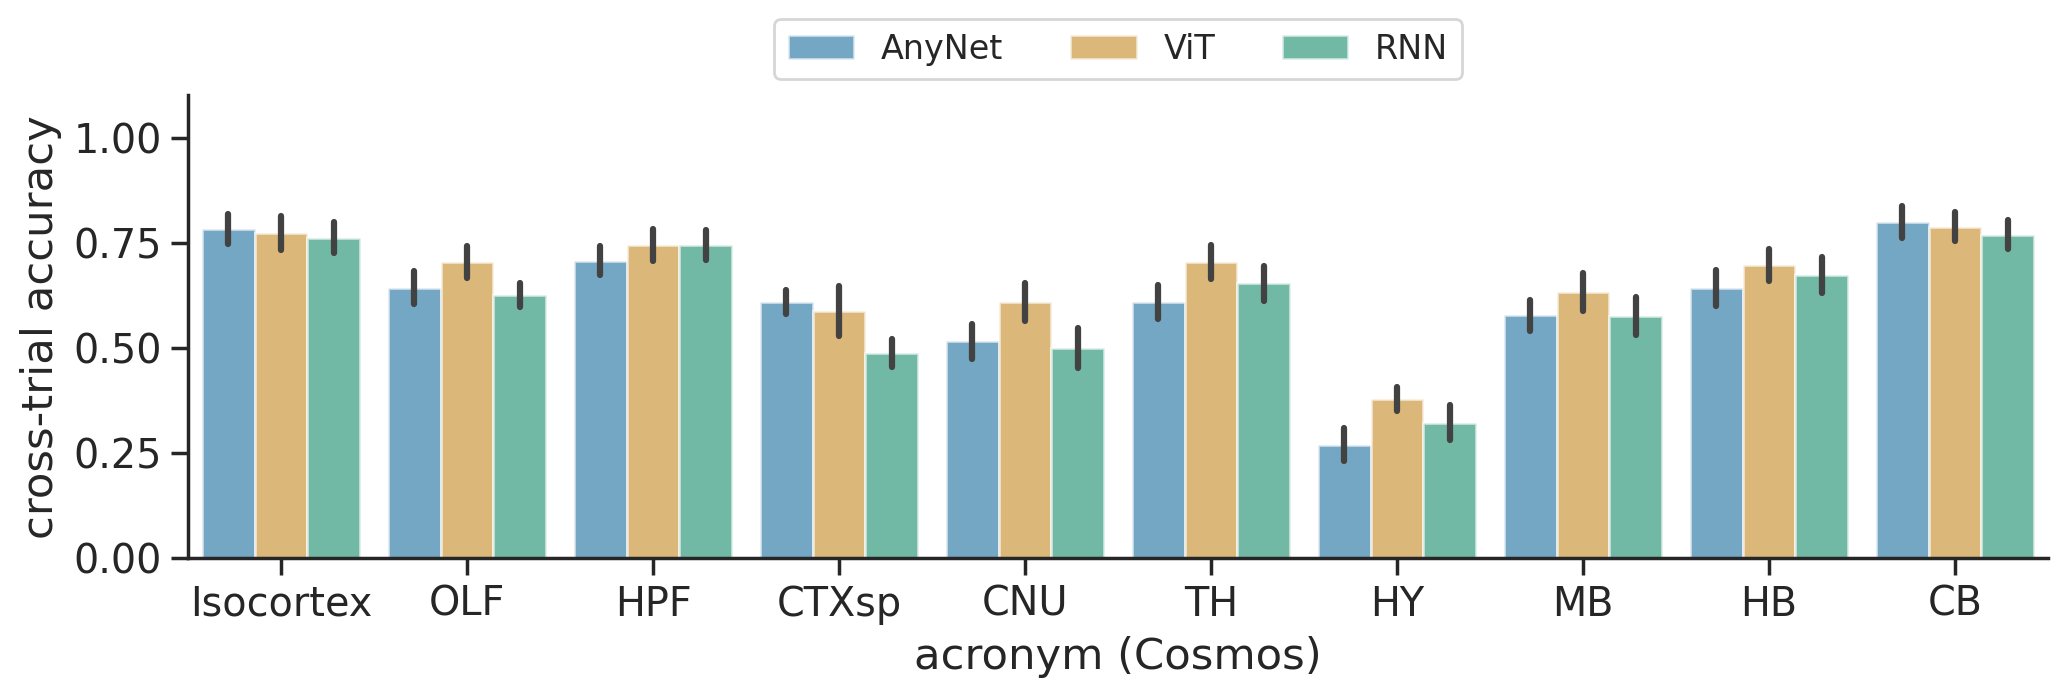

In [14]:
sns.set_theme(style='ticks', font_scale=1.3)
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(12, 3), dpi=200)
g = sns.barplot(
    data=Cosmos_acronym_accu_dict,
    x='acronym_test', y='acu_test', hue='model_type',
    errorbar='sd', width=0.85, palette=color_list, alpha=.6
)
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, title=None, fontsize=12)
# plt.plot([-0.5, 9.5], [0.6, 0.6], 'k--')
plt.xlim([-0.5, 9.5])
plt.ylim([0, 1.1])
plt.ylabel('cross-trial accuracy')
plt.xlabel('acronym (Cosmos)')
sns.despine()
# plt.legend(loc='lower left')
plt.show()

In [15]:
Cosmos_acronym_subject_accu_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu/Cosmos_dict_acronym_subject.pt', weights_only=False)

In [16]:
Cosmos_acronym_subject_accu_dict

,acu_test_subject,model_type,acronym_subject_test
0,0.609375,AnyNet,Isocortex
1,0.554688,AnyNet,Isocortex
2,0.453125,AnyNet,Isocortex
3,0.585938,AnyNet,Isocortex
4,0.429688,AnyNet,Isocortex
...,...,...,...
1495,0.570312,RNN,CB
1496,0.617188,RNN,CB
1497,0.531250,RNN,CB
1498,0.546875,RNN,CB


/tmp/ipython-input-1794537611.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.barplot(


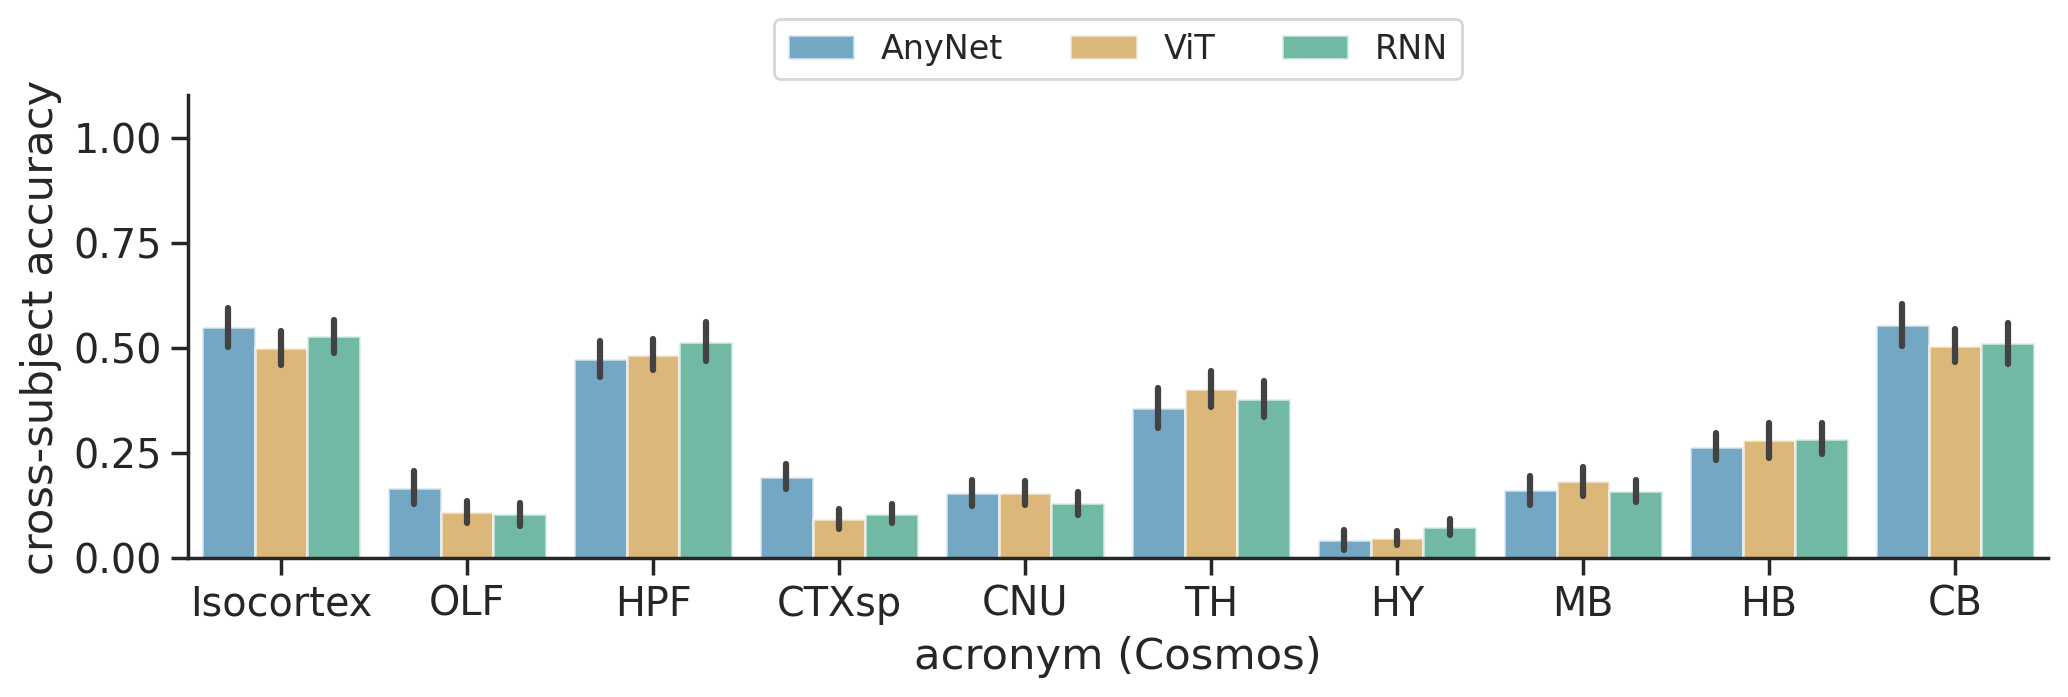

In [18]:
sns.set_theme(style='ticks', font_scale=1.3)
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(12, 3), dpi=200)
g = sns.barplot(
    data=Cosmos_acronym_subject_accu_dict,
    x='acronym_subject_test', y='acu_test_subject', hue='model_type',
    errorbar='sd', width=0.85, palette=color_list, alpha=.6
)
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, title=None, fontsize=12)
# plt.plot([-0.5, 9.5], [0.6, 0.6], 'k--')
plt.xlim([-0.5, 9.5])
plt.ylim([0, 1.1])
plt.ylabel('cross-subject accuracy')
plt.xlabel('acronym (Cosmos)')
sns.despine()
# plt.legend(loc='lower left')
plt.show()